In [18]:
import pandas as pd
import matplotlib.pyplot as plt


In [19]:
df = pd.read_csv('/Users/empressb/Desktop/tlab-shopping/shopping-behavior/data/processed/shopping_cleaned.csv')

In [20]:
df.head(10)

,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method
0,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,Present,Standard,No,0,Credit Card
1,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,Missing,Standard,No,0,Credit Card
2,26.0,Male,Leggings,23.595139,Nevada,XL,Brown,Winter,Missing,Standard,No,3,Credit Card
3,43.0,Male,Dress,34.079015,California,M,Terra cotta,Fall,Present,Standard,No,0,Credit Card
4,29.0,Male,Shorts,23.796439,Minnesota,M,Lavender,Summer,Present,Express,No,0,Credit Card
5,25.0,Female,Jacket,31.595005,Washington,M,Mauve,Fall,Present,Standard,No,4,Credit Card
6,39.0,Female,Shorts,32.374104,Colorado,M,Fuchsia,Summer,Missing,Standard,No,3,Credit Card
7,45.0,Female,Jacket,35.548978,Florida,M,Brown,Winter,Missing,Standard,No,10,Credit Card
8,23.0,Male,Backpack,34.437918,Texas,M,Brown,Winter,Missing,Standard,No,2,Credit Card
9,27.0,Female,Handbag,29.430620,Virginia,XL,Black,Summer,Missing,Standard,No,2,Credit Card


In [21]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    3158 non-null   float64
 1   Gender                 3158 non-null   object 
 2   Item Purchased         3158 non-null   object 
 3   Purchase Amount (USD)  3158 non-null   float64
 4   Location               3158 non-null   object 
 5   Size                   3158 non-null   object 
 6   Color                  3158 non-null   object 
 7   Season                 3158 non-null   object 
 8   Review Rating          3158 non-null   object 
 9   Shipping Type          3158 non-null   object 
 10  Promo Code Used        3158 non-null   object 
 11  Previous Purchases     3158 non-null   int64  
 12  Payment Method         3158 non-null   object 
dtypes: float64(2), int64(1), object(10)
memory usage: 320.9+ KB


How many rows and columns is in this dataset?

In [22]:
df.shape 

(3158, 13)

Lets take a look at the descriptive analysis of the dataset

In [23]:
df.describe()

,Age,Purchase Amount (USD),Previous Purchases
count,3158.000000,3158.000000,3158.000000
mean,34.185244,38.812750,5.860988
std,10.578195,11.525595,5.844408
min,18.000000,11.946095,0.000000
25%,26.000000,29.419108,1.000000
50%,33.000000,37.126663,4.000000
75%,41.000000,48.974363,9.000000
max,73.000000,68.327455,20.000000


# **Now its time to start the exploratory data analysis on our shopping dataset**

## 1. Which season has the highest purchasing amount?


In [40]:
df.groupby('Season')['Purchase Amount (USD)'].max()

Season
Fall      68.327455
Spring    64.811363
Summer    66.589262
Winter    67.616842
Name: Purchase Amount (USD), dtype: float64

In [41]:
popular_season = (df.groupby('Season')['Purchase Amount (USD)']
                  .sum()
                .reset_index(name ='High Purchase Amount')
                .sort_values("High Purchase Amount", ascending = False)
       

)

popular_season.style.format({'High Purchase Amount' : '${: .2f}'})

,Season,High Purchase Amount
3,Winter,$ 40168.10
0,Fall,$ 33953.96
2,Summer,$ 29642.92
1,Spring,$ 18805.68


## The highest purchasing amount of $40,168.10 took place during the winter season in my shopping dataset!

## 2. What are the most popular colors by season?

In [42]:
popular_colors= (
    df.groupby(['Color', 'Season']).size()
    .reset_index(name = 'Count')
    .sort_values('Count', ascending=False)
    .groupby('Season')
    .first()
    .reset_index())

popular_colors

,Season,Color,Count
0,Fall,Brown,97
1,Spring,Baby blue,69
2,Summer,Lavender,102
3,Winter,Black,124


## I wanted to be very specific on finding the most popular color per season so I made sure to group using multiple columns and then groupby again for season.  Black is the popular color for Winter and I was surpsrise to see that Lavender was the most popular color for  Summer.

# 3.   Which payment method is most used among consumers?

In [44]:
popular_method = (
    df.groupby('Age')['Payment Method']
        .max()
        .reset_index(name ='Popular Choice')
        .sort_values("Popular Choice", ascending = False)
    
)
popular_method

,Age,Popular Choice
0,18.0,Venmo
26,44.0,Venmo
28,46.0,Venmo
29,47.0,Venmo
30,48.0,Venmo
31,49.0,Venmo
32,50.0,Venmo
33,51.0,Venmo
34,52.0,Venmo
35,53.0,Venmo


## This chart is not showing what I need to find out which payment method is popular amoung the age groups. Lets first create a new column for age groups and then  create a pivot table

In [45]:
bins =[18,25,40,65,80]
labels = ['18-25', '26-40', '41-65', '66-80']


df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

In [46]:
df

,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Age Group
0,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,Present,Standard,No,0,Credit Card,26-40
1,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,Missing,Standard,No,0,Credit Card,26-40
2,26.0,Male,Leggings,23.595139,Nevada,XL,Brown,Winter,Missing,Standard,No,3,Credit Card,26-40
3,43.0,Male,Dress,34.079015,California,M,Terra cotta,Fall,Present,Standard,No,0,Credit Card,41-65
4,29.0,Male,Shorts,23.796439,Minnesota,M,Lavender,Summer,Present,Express,No,0,Credit Card,26-40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3153,39.0,Male,Running Shoes,55.636680,Kansas,L,White,Summer,Missing,2-Day Shipping,Yes,11,Venmo,26-40
3154,43.0,Female,Sunglasses,61.610602,Colorado,S,Burnt orange,Fall,Missing,2-Day Shipping,Yes,7,Venmo,41-65
3155,37.0,Male,Pajamas,44.600556,Alaska,S,Aubergine,Winter,Present,2-Day Shipping,Yes,20,Venmo,26-40
3156,39.0,Male,Hoodie,45.343778,Illinois,S,Brick red,Fall,Missing,2-Day Shipping,Yes,3,Venmo,26-40


## The age group column was created and added to the end of the dataset

In [48]:
payment_pivot = df.pivot_table(
       index='Age Group',
       columns= 'Payment Method',
       values = 'Age',
       aggfunc='count',
       fill_value =0
)

payment_pivot

Payment Method,Bank Transfer,Cash,Credit Card,Debit Card,PayPal,Venmo
Age Group,,,,,,
18-25,0,0,247,225,93,97
26-40,0,0,585,541,246,221
41-65,6,6,287,249,138,126
66-80,4,3,0,1,4,5


In [49]:
payment_pivot['Most Popular'] =payment_pivot.idxmax(axis=1)

In [50]:
payment_pivot

Payment Method,Bank Transfer,Cash,Credit Card,Debit Card,PayPal,Venmo,Most Popular
Age Group,,,,,,,
18-25,0,0,247,225,93,97,Credit Card
26-40,0,0,585,541,246,221,Credit Card
41-65,6,6,287,249,138,126,Credit Card
66-80,4,3,0,1,4,5,Venmo


## Credit card is the most popular form of payment method across all age groups except 66-80, who perfer Venmo. Notably, younger shoppers (18-25 and 26-40) had zero cash or bank transfer usage."

# 4. What is the most popular clothing item by season?

In [54]:
popular_item= (
    df.groupby(['Item Purchased', 'Season']).size()
    .reset_index(name = 'Count')
    .sort_values('Count', ascending=False)
    .groupby('Season')
    .first()
    .reset_index())

popular_item

,Season,Item Purchased,Count
0,Fall,Sweater,72
1,Spring,Running Shoes,89
2,Summer,Shorts,152
3,Winter,Leggings,118


# 5. What are the top 5 states that have the highest purchasing amount? 

In [55]:
top_states = (df.groupby('Location')['Purchase Amount (USD)']
            .sum()  
            .reset_index(name='Total Spend')
            .sort_values('Total Spend', ascending= False) 
            .head(5)
              
              
              )
top_states

,Location,Total Spend
4,California,3115.704856
26,Nebraska,2836.962269
7,Delaware,2802.469847
25,Montana,2795.195079
47,West Virginia,2789.993478


## California was the #1 state with  the highest purchasing amount of $3,115.70 followed by Nebraska with $2,836 now lets create a bar graph to highlght my findings. 

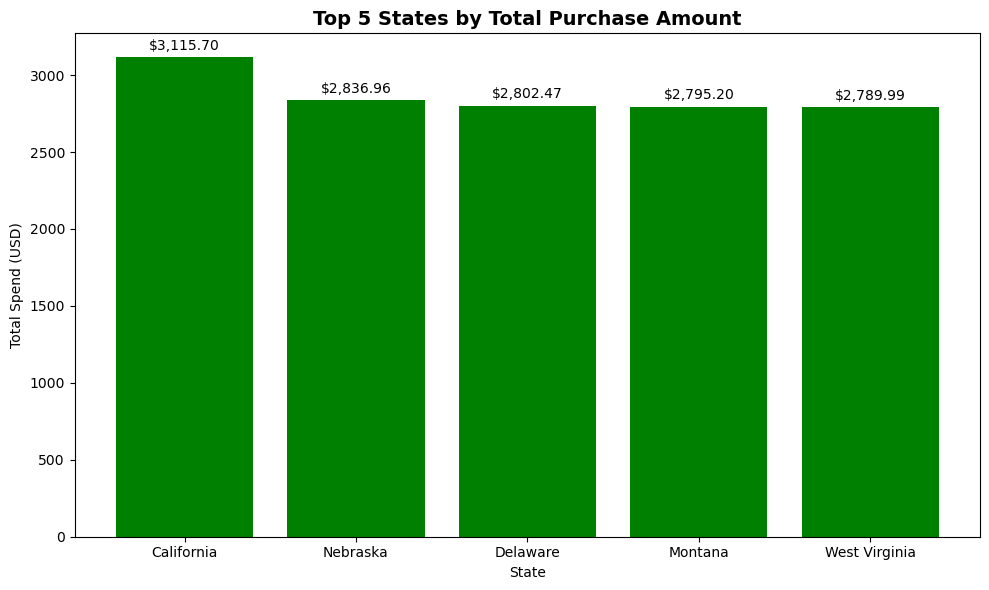

In [61]:
plt.figure(figsize=(10,6))
plt.bar(top_states['Location'],
        top_states['Total Spend'],
        color='Green')
#Add labels on top of bars
for i, value in enumerate(top_states['Total Spend']):
    plt.text(i, value + 50, f'${value:,.2f}', ha='center',fontsize=10)
plt.title('Top 5 States by Total Purchase Amount', fontsize =14,
          fontweight='bold')
plt.xlabel('State')
plt.ylabel('Total Spend (USD)')
plt.tight_layout()
plt.show()

# 6.  What is the effect of promo codes on the dollar amount of purchases?

In [62]:
promo_effect = (df.groupby('Promo Code Used') ['Purchase Amount (USD)']
               .mean()
               .reset_index(name='Avg Purchase Amount')
                )
promo_effect
               

,Promo Code Used,Avg Purchase Amount
0,No,30.155751
1,Yes,50.067480


# Customers who used a promo code had a higher average purchase amount ($50.07) compared to those who didn't ($30.16) This indicates that promo codes drive higher spending per transaction.

# 7. Which age groups use the most promo codes ?

In [65]:
promo_agegroup = (df.groupby(['Age Group', 'Promo Code Used'])
                  .size()
                  .reset_index(name= 'Top Users')
                  .sort_values('Top Users', ascending=False)
                  )
promo_agegroup

,Age Group,Promo Code Used,Top Users
2,26-40,No,904
3,26-40,Yes,689
4,41-65,No,464
0,18-25,No,370
5,41-65,Yes,348
1,18-25,Yes,292
7,66-80,Yes,10
6,66-80,No,7


## According to the results, the 26-40 age group used the most promo codes (689) and also had the highest count of non-users(904), likely because it is the largest group overall.    Surprisingly, the 18-25 group had fewer  promo codes users (292) than non-users (370), suggesting younger consumers may be less motivated by discounts.

# 8.  When do users leave a review?

## This  question is very broad and needs to be reworded in order to tackle the question from a specific angle. I am going to focus on how does purchase amount relate to a consumer actually leaving a review. 

# 8a. Which purchase amount range leads to consumers leaving reviews?

In [66]:
bins =[0,25,50,75,100]
labels = ['0-25', '26-50', '51-75', '76-100']

df['Purchase Range'] = pd.cut(df['Purchase Amount (USD)'], bins=bins, labels=labels)


In [67]:
review_pivot = df.pivot_table(
         index ='Purchase Range',
         columns ='Review Rating',
         values = 'Purchase Amount (USD)',
         aggfunc ='count',
         fill_value =0


)

review_pivot

Review Rating,Missing,Present
Purchase Range,,
0-25,236,131
26-50,1348,761
51-75,436,246
76-100,0,0


## Consumers who spent between $26-50 were the most likely  to leave a review(761 Present), but also had the highest number of missing reviews(1,348). No purchases exceeded $75 in this dataset. This raises a further question-- what truly compels a consumer to leave a review? A follow-up analysis comparing promo code usage to review presence could provide more clarity.

# Conclusion

## In this exploratory data analysis of the shopping behavior dataset, several key findings emerged. California was the top spending state, with most purchases falling in the $26-50 range. Winter was the highest spending season, with black being the most popular color. Credit card was the dominant payment method across most age groups. Promo codes had a significant impact on purchase amount, with promo code users spending nearly $20 more on average. Further analysis is recommended to explore what drives consumers to leave reviews  and the relationship between promo codes and review behavor.